# Dataset Sintético de Evasão Escolar

Este notebook gera um dataset sintético com base em variáveis relacionadas à evasão escolar no ensino público do Distrito Federal. As variáveis foram definidas previamente e incluem dados do estudante, família, comunidade, escola e professores.

# Definição de evasão escolar

- Precisamos de uma definição clara de evasão escolar. Exemplo, faltou mais de 30 dias seguidos?! 
- O ideal é seguir a definição do MEC, que considera evasão escolar a falta não justificada por mais de 15 dias consecutivos, conforme ChatGPT (temos que confirmar e pegar a fonte).
- Ou podemos considerar uma definição razoável usada em outros trabalhos acadêmicos.

# Propriedades de atributos

- Precisamos definir melhor as propriedades de cada atributo para facilitar a síntese de dados. Exemplo:
  - Sexo: variável categórica (masculino, feminino, "não informado" ?). Qual a proporção de cada categoria? Se não houver, podemos usar dados do IBGE.
  - Idade: variável numérica. Qual a média, mediana e desvio padrão? OU proporção entre esses, considerando uma variável categórica.

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import truncnorm

# Configurações iniciais
n_alunos = 100000  # número de registros

In [109]:
sexos = ['Masculino', 'Feminino', 'Outro']
# etapas = ['5º ano', '6º ano', '7º ano', '8º ano', '9º ano', '1ª série EM', '2ª série EM', '3ª série EM']
# niveis_socioeconomicos = [f'N{i}' for i in range(1, 8)]
apoio_familiar_vals = ['Alto', 'Médio', 'Baixo']
comportamento_vals = ['Bom', 'Regular', 'Ruim']
aceitacao_vals = ['Alta', 'Média', 'Baixa']
expectativa_vals = ['Alta', 'Média', 'Baixa']
engajamento_vals = ['Alto', 'Moderado', 'Baixo']
infraestrutura_vals = ['Boa', 'Regular', 'Ruim']
material_vals = ['Completa', 'Parcial', 'Insuficiente']
flex_pedagogica_vals = ['Alta', 'Média', 'Baixa']
qualidade_pedagogica_vals = ['Boa', 'Regular', 'Ruim']

idades=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

In [110]:
# Variáveis
proporcao_evasao = 0.1 # Supondo que 10% dos alunos evadem

pesos_idades=[1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13]
pesos_idades_evadiu=[0.5/13, 1.5/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13]

In [ ]:
def gerar_idade(evadiu:bool):
    if evadiu:
        return random.choices(idades, weights=pesos_idades_evadiu)[0]
    else:
        return random.choices(idades, weights=pesos_idades)[0]

def gerar_distancia():
    return round(abs(np.random.normal(2, 1)), 1)

def gerar_sexo(evadiu:bool):
    if evadiu:
        return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]  # Evadidos têm menos diversidade de sexo
    else:
        return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]  # Proporção de não evadidos

def gerar_frequencia():
    media = 85
    desvio = 10

    a, b = (0 - media) / desvio, (100 - media) / desvio  # limites normalizados
    notas = truncnorm.rvs(a, b, loc=media, scale=desvio, size=n_alunos)
    return notas

def gerar_nota():
    distribuicao = {
        (0, 5): 0.25,   # 25% dos alunos com média até 5
        (5, 7): 0.35,   # 35% entre 5 e 7
        (7, 10): 0.40   # 40% entre 7 e 10
    }
    
    # selecionar faixa com base nas probabilidades
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
    
    # ordena nota uniforme dentro da faixa
    nota = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    
    return round(nota, 1) 

def gerar_niveis_socioeconomicos():

    distribuicao = {
        "Muito baixo": 0.10,
        "Baixo": 0.30,
        "Médio": 0.40,
        "Alto": 0.15,
        "Muito alto": 0.05
    }

    categorias = list(distribuicao.keys())
    probs = list(distribuicao.values())
    
    return np.random.choice(categorias, p=probs)

def gerar_renda():
    distribuicao = {
        (0,1): 0.05,
        (1,2): 0.35,
        (2,5): 0.45,
        (5,10): 0.10,
        (10, np.inf): 0.05
    }
    
    # escolher faixa com base nas probabilidades
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
    
    # sortear renda dentro da faixa
    if np.isinf(faixa_escolhida[1]):
        renda_sm = np.random.uniform(faixa_escolhida[0], faixa_escolhida[0] * 2)
    else:
        renda_sm = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    
    # converter para reais
    salario_min = 1139.4    # media do salario minimo dos ultimos 10 anos 
    renda_reais = renda_sm * salario_min
    
    return round(renda_reais, 2)

def gerar_etapa_ensino(evadiu: bool):
    # todas as listas seguintes seguem essa ordem
    etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF", \
              "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

    # dados do censo escolar de 2023(ultimo ano disponivel c/ porcentagens de evasao)
    total_matriculas = 400686 - 48259       # total de matriculas - matriculas Edu. Infantil
    qtd_matriculas_etapas = [28087, 29163, 33253, 28054, 28682, 29944, \
                    30364, 28886, 30368, 31195, 29372, 25056]
    
    # calcula a distribuicao da proporcao de alunos por etapa
    distr_etapas = [i/total_matriculas for i in qtd_matriculas_etapas]

    percentual_evasao_etapa = [0.002, 0.001, 0.002, 0.002, 0.002, 0.01, \
                   0.014, 0.012, 0.018, 0.04, 0.046, 0.03]      # dados do censo escolar de 2023
    
    # calcula a distribuicao de abandonos
    evadidos_por_etapa = [qtd_matriculas_etapas[i] * percentual_evasao_etapa[i] for i in range(len(etapas))]
    total_evadidos = sum(evadidos_por_etapa)
    distr_etapas_evasao = [i/total_evadidos for i in evadidos_por_etapa]

    if evadiu:
        return random.choices(etapas, weights=distr_etapas)[0]
    else:
        return random.choices(etapas, weights=distr_etapas_evasao)[0]    

In [ ]:

serie_evasao:list[bool] = [random.choices([True, False], weights=[proporcao_evasao, 1 - proporcao_evasao])[0] for _ in range(n_alunos) ]

# Criação do DataFrame
df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'evasao': serie_evasao,  # atributo que eu tenho e quero estimar
    'sexo': [gerar_sexo(evadir) for evadir in serie_evasao],
    'idade': [gerar_idade(evadir) for evadir in serie_evasao],
    # Novas variaveis
    'estudante_nis': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'informou_nome_mae': np.random.choice([True, False], n_alunos, p=[0.95, 0.05]),
    'informou_nome_pai': np.random.choice([True, False], n_alunos, p=[0.7, 0.3]),
    'possui_deficiencia': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'raca_cor': np.random.choice(
        ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada'],
        n_alunos,
        p=[0.35, 0.1, 0.45, 0.05, 0.02, 0.03]
    ),
    'tipo_localizacao_endereco_estudante': np.random.choice(
        ['Urbana', 'Rural'],
        n_alunos,
        p=[0.8, 0.2]
    ),
    'situacao_consolidada_no_ano': np.random.choice(
        ['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'],
        n_alunos,
        p=[0.7, 0.15, 0.1, 0.05]
    ),
    'etapa_ensino': [gerar_etapa_ensino(i) for i in serie_evasao],
    'repetente': np.random.choice([True, False], n_alunos, p=[0.047, 0.953]),
    'frequencia_escolar': gerar_frequencia(),    
    'notas_medias': [gerar_nota() for _ in range(n_alunos)],
    'nivel_socioeconomico': [gerar_niveis_socioeconomicos() for _ in range(n_alunos)],
    'renda_familiar': [gerar_renda() for _ in range(n_alunos)],
    
    
    'trabalha': np.random.choice([True, False], n_alunos, p=[0.15, 0.85]),
    'trabalho_domestico_excessivo': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'problemas_de_saude': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'violencia_domestica': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'gravidez_na_adolescencia': np.random.choice([True, False], n_alunos, p=[0.03, 0.97]),
    'apoio_familiar': np.random.choice(apoio_familiar_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'comportamento_em_sala': np.random.choice(comportamento_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'aceitacao_pelos_pares': np.random.choice(aceitacao_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'necessita_assistencia_social': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'expectativa_retorno': np.random.choice(expectativa_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'fator_desencadeador_presente': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'distancia_da_escola_km': [gerar_distancia() for _ in range(n_alunos)],
    'violencia_na_comunidade': np.random.choice([True, False], n_alunos, p=[0.2, 0.8]),
    'engajamento_com_a_escola': np.random.choice(engajamento_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'infraestrutura_escolar': np.random.choice(infraestrutura_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'disponibilidade_material_didatico': np.random.choice(material_vals, n_alunos, p=[0.6, 0.3, 0.1]),
    'flexibilidade_pedagogica': np.random.choice(flex_pedagogica_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'qualidade_pedagogica_percebida': np.random.choice(qualidade_pedagogica_vals, n_alunos, p=[0.5, 0.3, 0.2])
})

# # Pontuação de risco
df['pontuacao_risco'] = (
     (100 - df['frequencia_escolar']) / 100 * 0.3 +
     (10 - df['notas_medias']) / 10 * 0.3 +
     df['repetente'].astype(int) * 0.1 +
     df['trabalha'].astype(int) * 0.1 +
     df['violencia_domestica'].astype(int) * 0.2
 )

df['pontuacao_risco'] = df['pontuacao_risco'] / df['pontuacao_risco'].max()

# # Evasão confirmada
df['evasao_confirmada'] = [np.random.rand() < r for r in df['pontuacao_risco']]


In [ ]:
df['etapa_ensino'].head()

0        9° EF
1        6° EF
2        1° EM
3        1° EM
4        7° EF
         ...  
99995    1° EM
99996    2° EM
99997    2° EM
99998    3° EM
99999    9° EF
Name: etapa_ensino, Length: 100000, dtype: object

In [114]:
# Visualização da distribuição da pontuação de risco
# plt.hist(df['pontuacao_risco'], bins=20, edgecolor='black')
# plt.title('Distribuição da Pontuação de Risco')
# plt.xlabel('Pontuação de risco')
# plt.ylabel('Quantidade de alunos')
# plt.show()

## Análise Exploratória

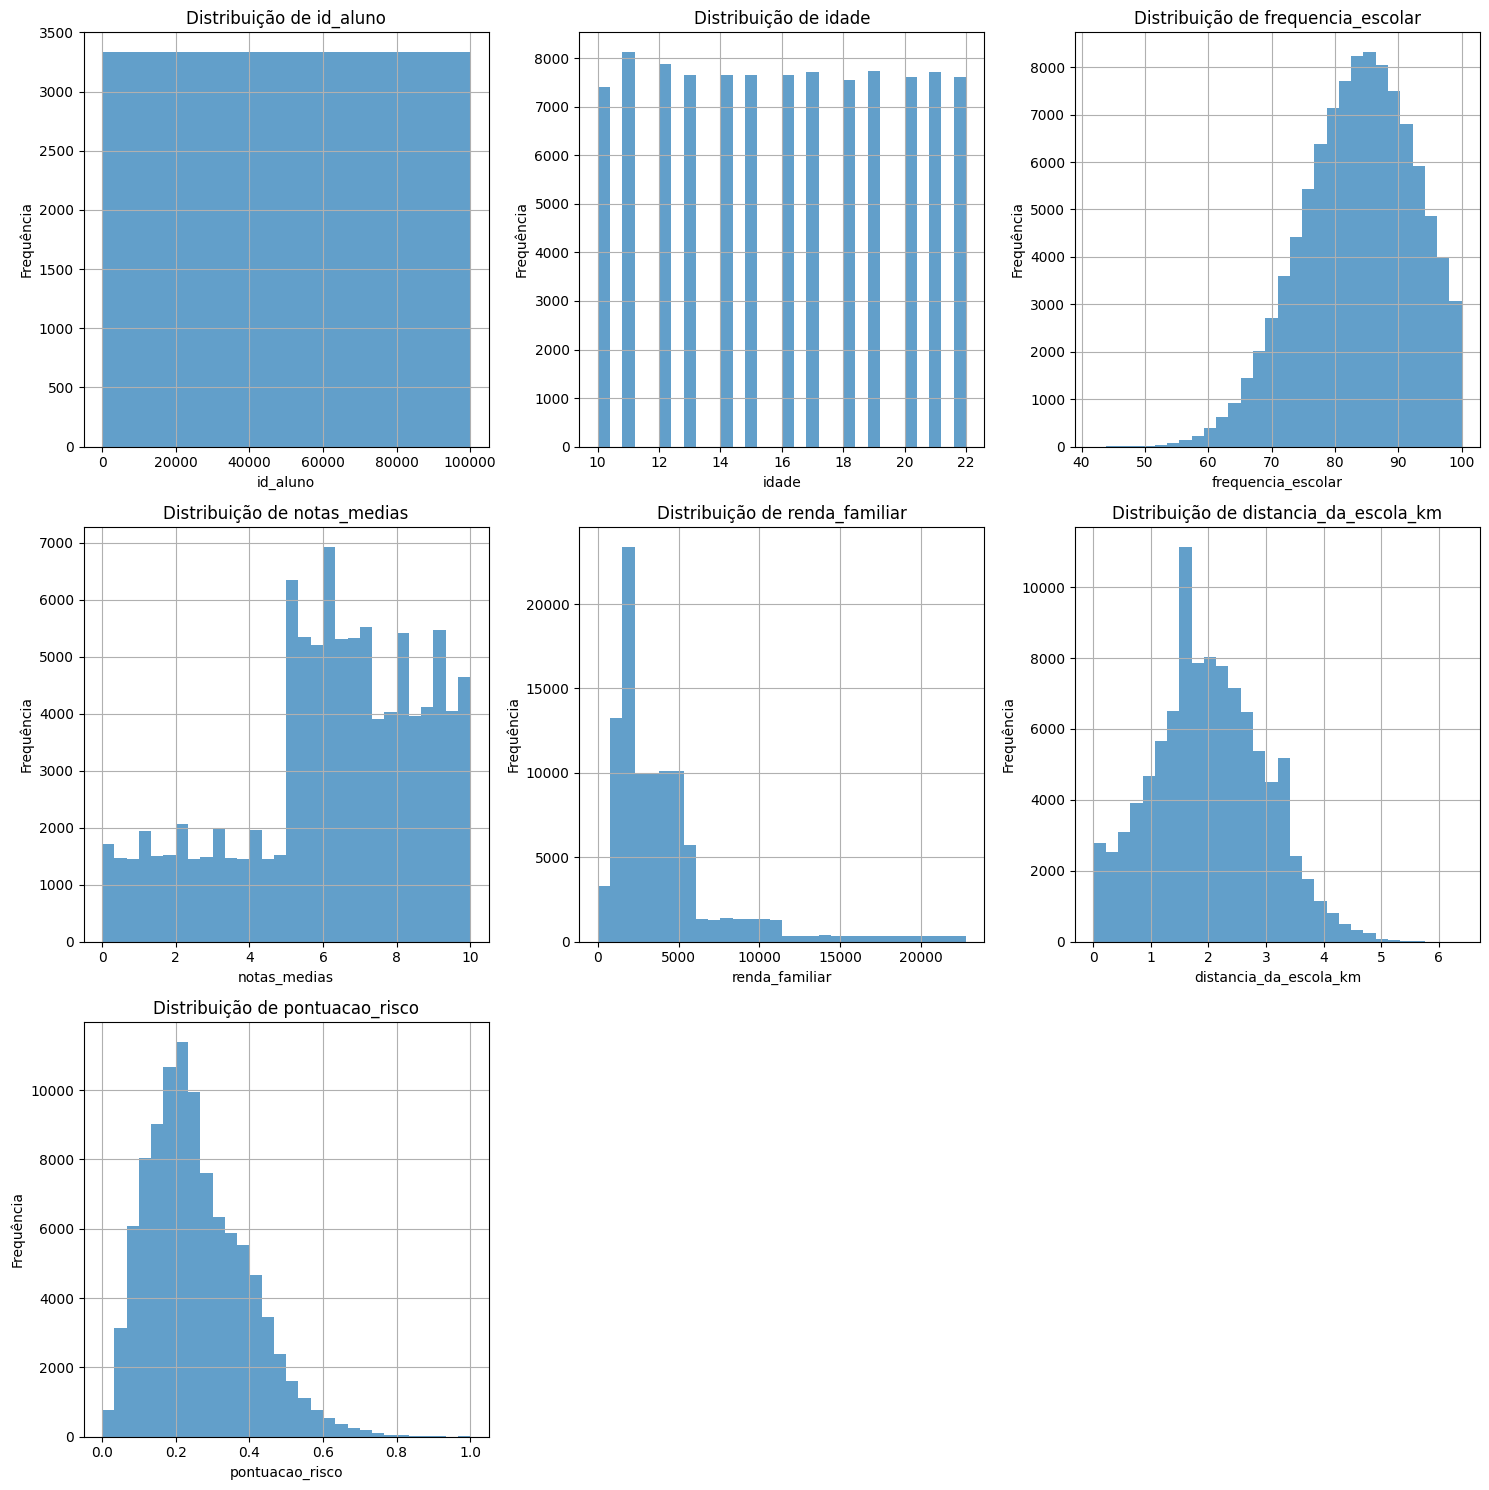

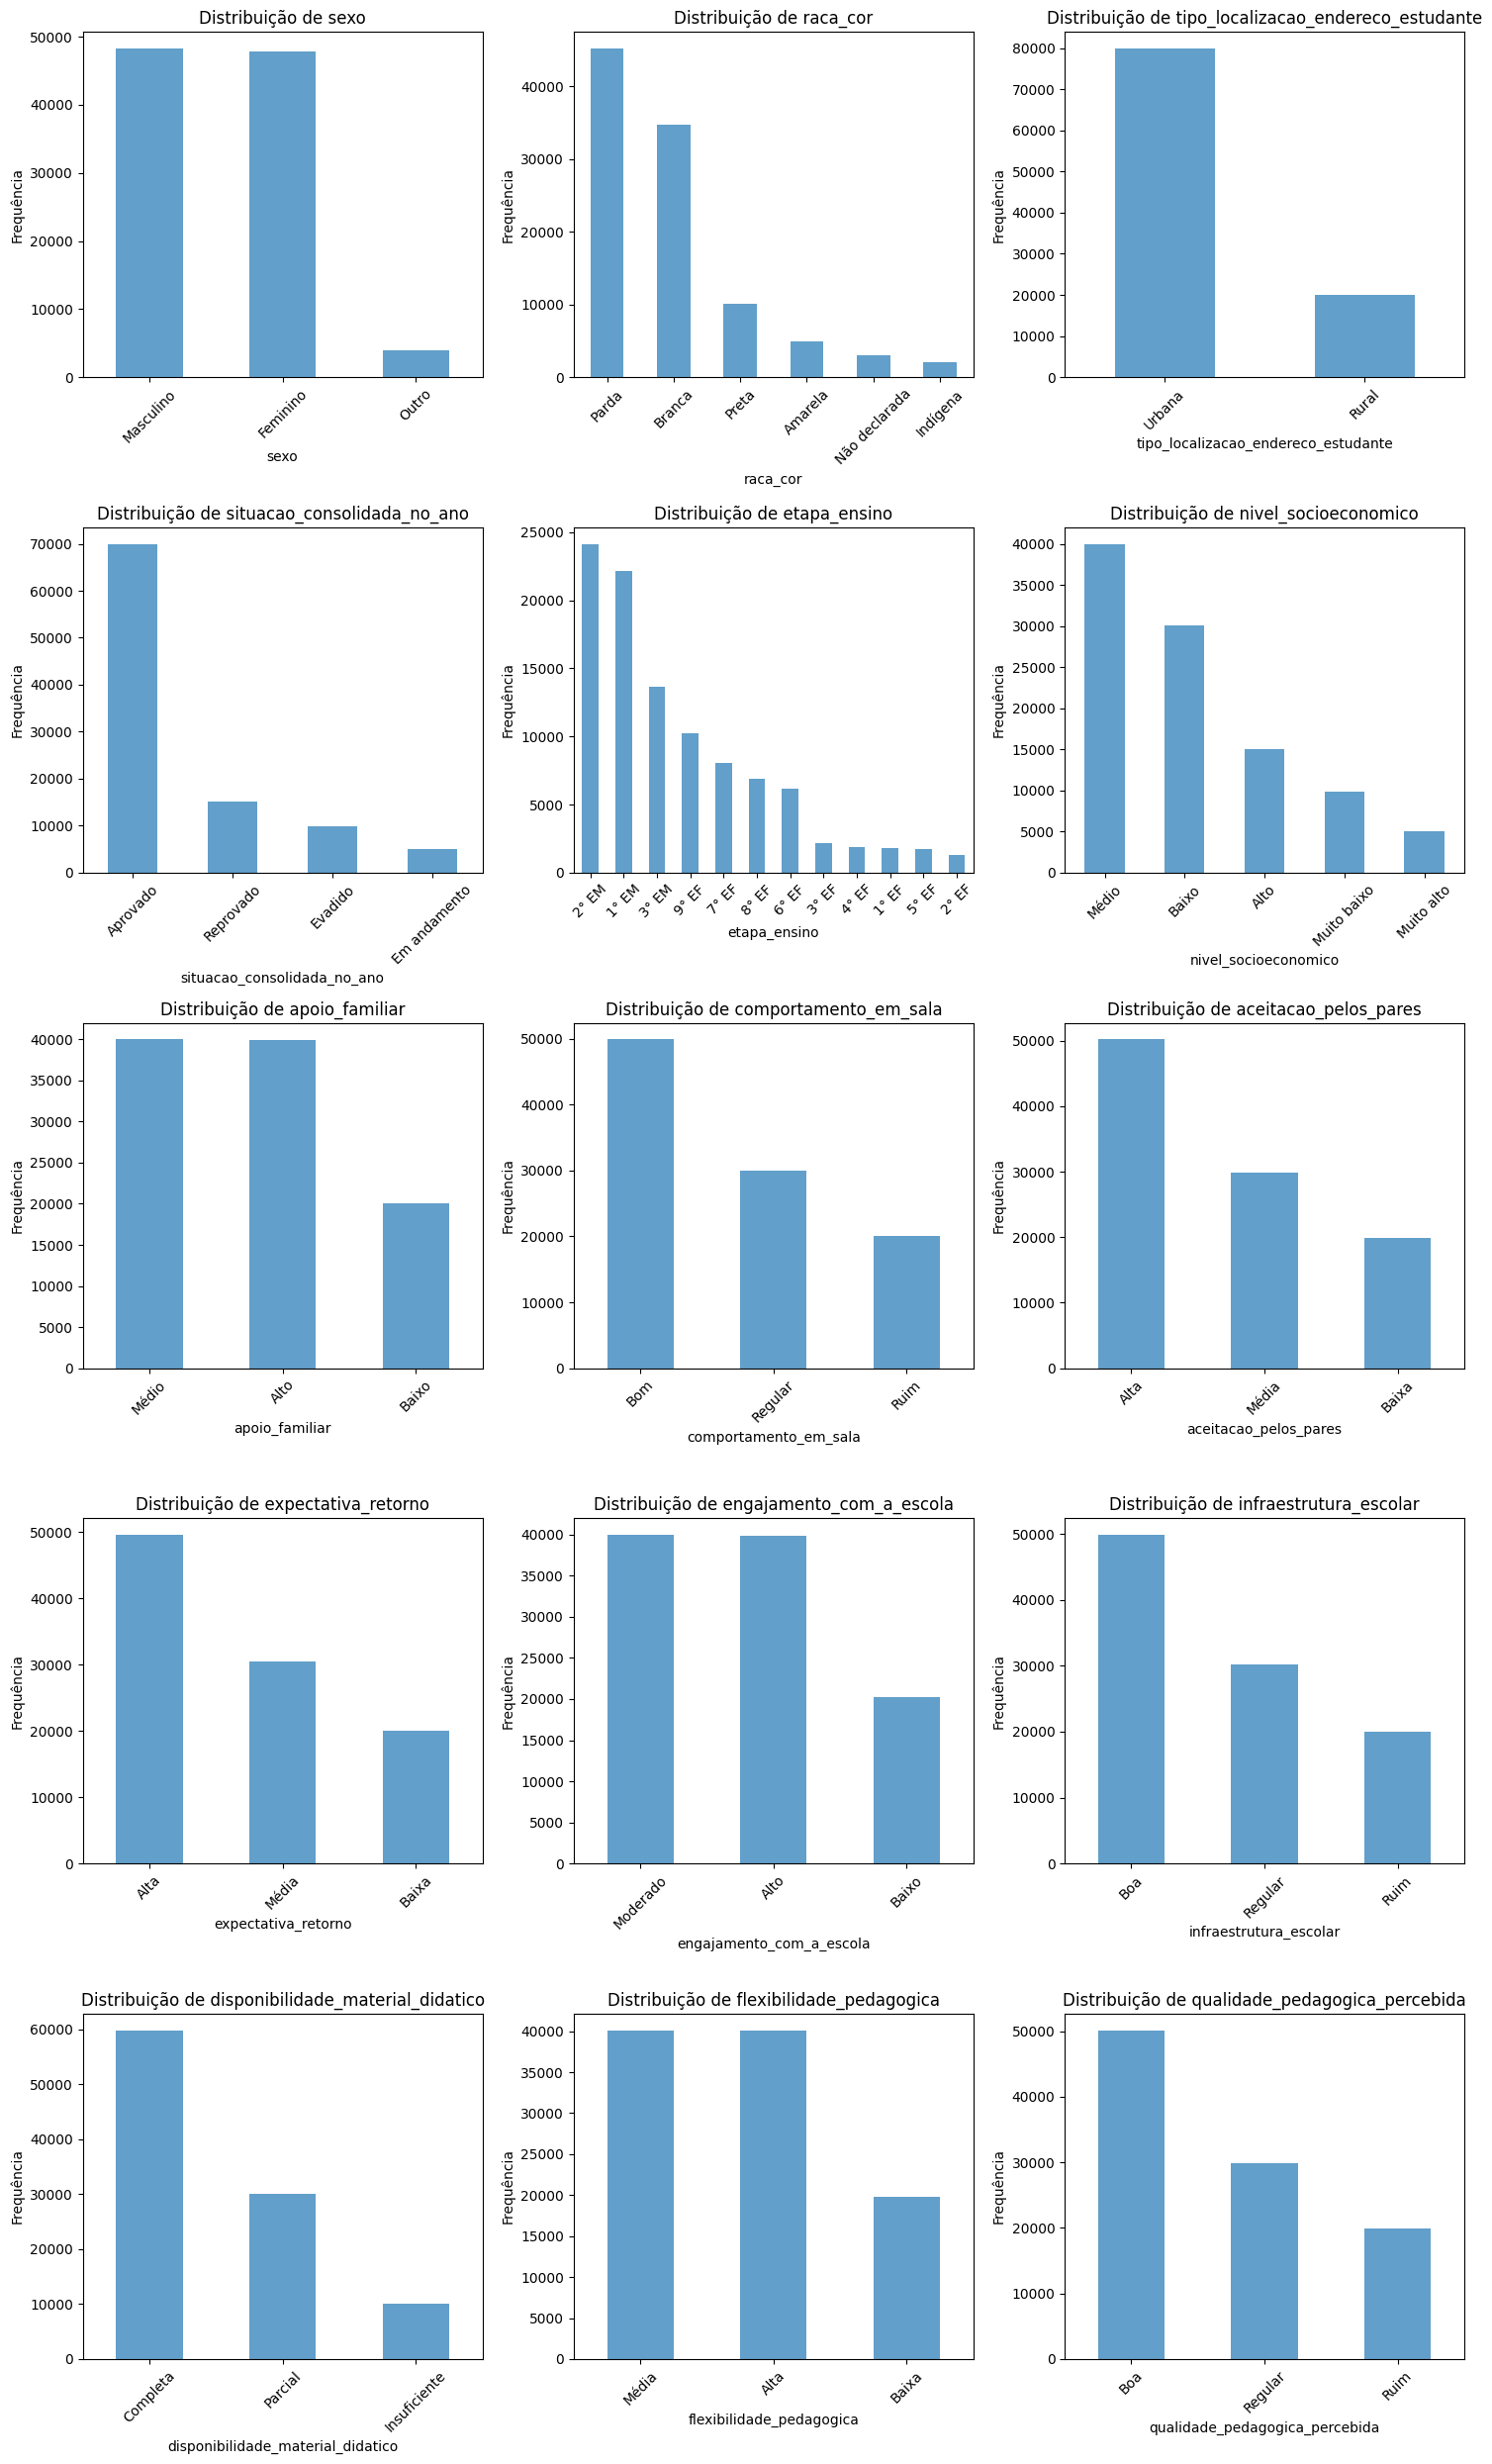

In [115]:
def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Para variáveis categóricas (gráficos de barras)
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
plot_categorical_distributions(df)

In [116]:
# Salvar dataset em CSV
df.to_csv('dataset_evasao_sintetico.csv', index=False)
print('Dataset salvo como dataset_evasao_sintetico.csv')

Dataset salvo como dataset_evasao_sintetico.csv
